In [1]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

import sys
print(sys.executable)  # должен вести в conda env tf-gpu
print(tf.__version__)

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
C:\Users\User\.conda\envs\tf-gpu\python.exe
2.10.0


In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Пути к данным
base_path = 'data/UCI HAR Dataset'
train_path = f'{base_path}/train'
test_path = f'{base_path}/test'

# Загрузка сырых сигналов (9 каналов: body_acc_xyz, body_gyro_xyz, total_acc_xyz)
def load_signals(path, split):
    signals = []
    for sensor in ['body_acc', 'body_gyro', 'total_acc']:
        for axis in ['x', 'y', 'z']:
            file_path = f'{path}/Inertial Signals/{sensor}_{axis}_{split}.txt'
            signals.append(np.loadtxt(file_path))
    return np.stack(signals, axis=-1)  # (samples, 128, 9)

# Загрузка меток
def load_labels(path, split):
    return np.loadtxt(f'{path}/y_{split}.txt', dtype=int) - 1  # 0-indexed

# Загрузка train и test
X_train_full = load_signals(train_path, 'train')  # (7352, 128, 9)
y_train_full = load_labels(train_path, 'train')
X_test = load_signals(test_path, 'test')          # (2947, 128, 9)
y_test = load_labels(test_path, 'test')

# Загрузка subject IDs
subject_train = np.loadtxt('data/UCI HAR Dataset/train/subject_train.txt', dtype=int)
subject_test = np.loadtxt('data/UCI HAR Dataset/test/subject_test.txt', dtype=int)

# Рандомный выбор val subjects
unique_train_subjects = np.unique(subject_train)
np.random.seed(42)
val_subjects = np.random.choice(unique_train_subjects, size=5, replace=False)
train_subjects = np.setdiff1d(unique_train_subjects, val_subjects)

# Маски
val_mask = np.isin(subject_train, val_subjects)
train_mask = np.isin(subject_train, train_subjects)

X_train = X_train_full[train_mask]
y_train = y_train_full[train_mask]
X_val = X_train_full[val_mask]
y_val = y_train_full[val_mask]

# Нормализация (fit на train, transform на val/test)
# Для каждого канала отдельно: mean/std по всем samples и timesteps
scaler = StandardScaler()
n_samples, n_timesteps, n_channels = X_train.shape

# Reshape для нормализации: (samples * timesteps, channels)
X_train_reshaped = X_train.reshape(-1, n_channels)
X_val_reshaped = X_val.reshape(-1, n_channels)
X_test_reshaped = X_test.reshape(-1, n_channels)

X_train_scaled = scaler.fit_transform(X_train_reshaped).reshape(X_train.shape)
X_val_scaled = scaler.transform(X_val_reshaped).reshape(X_val.shape)
X_test_scaled = scaler.transform(X_test_reshaped).reshape(X_test.shape)

print(f"Train: {X_train_scaled.shape}, Val: {X_val_scaled.shape}, Test: {X_test_scaled.shape}")
print(f"Train subjects ({len(train_subjects)}): {train_subjects}")
print(f"Val subjects ({len(val_subjects)}): {val_subjects}")
print(f"Shape: (samples, timesteps=128, channels=9)")

Train: (5551, 128, 9), Val: (1801, 128, 9), Test: (2947, 128, 9)
Train subjects (16): [ 5  6  7  8 11 14 16 17 19 21 22 23 26 28 29 30]
Val subjects (5): [ 1 27 25  3 15]
Shape: (samples, timesteps=128, channels=9)


In [3]:
# === Аугментации для временных рядов ===
def augment_jitter(x, sigma=0.01):
    """Добавление шума к каждому значению"""
    return x + np.random.normal(0, sigma, x.shape)

def augment_scaling(x, sigma=0.1):
    """Масштабирование сигналов"""
    scale_factor = np.random.normal(1.0, sigma, size=(x.shape[0], 1, x.shape[2]))
    return x * scale_factor

def augment_time_warp(x, sigma=0.2):
    """Случайное растяжение/сжатие времени"""
    batch_size, timesteps, channels = x.shape
    augmented = np.zeros_like(x)
    
    for i in range(batch_size):
        # Случайное количество контрольных точек
        n_control = np.random.randint(3, 6)
        control_points = np.sort(np.random.randint(0, timesteps, n_control))
        control_points = np.concatenate([[0], control_points, [timesteps-1]])
        
        # Случайные смещения
        offsets = np.random.normal(0, sigma * timesteps, n_control + 2)
        offsets[0] = 0
        offsets[-1] = 0
        
        # Интерполяция новых временных меток
        new_time = np.zeros(timesteps)
        for j in range(len(control_points) - 1):
            start, end = control_points[j], control_points[j+1]
            new_start = start + offsets[j]
            new_end = end + offsets[j+1]
            new_time[start:end] = np.linspace(new_start, new_end, end - start)
        
        # Интерполяция значений
        for c in range(channels):
            augmented[i, :, c] = np.interp(np.arange(timesteps), new_time, x[i, :, c])
    
    return augmented

def augment_batch(X, y, augmentation_prob=0.5):
    """Применяет случайные аугментации к батчу"""
    batch_size = X.shape[0]
    augmented_X = X.copy()
    
    for i in range(batch_size):
        if np.random.random() < augmentation_prob:
            # Случайный выбор аугментации
            aug_type = np.random.choice(['jitter', 'scaling', 'time_warp', 'combined'])
            
            sample = X[i:i+1]
            if aug_type == 'jitter':
                augmented_X[i] = augment_jitter(sample)[0]
            elif aug_type == 'scaling':
                augmented_X[i] = augment_scaling(sample)[0]
            elif aug_type == 'time_warp':
                augmented_X[i] = augment_time_warp(sample)[0]
            elif aug_type == 'combined':
                sample = augment_jitter(sample)
                sample = augment_scaling(sample)
                augmented_X[i] = sample[0]
    
    return augmented_X, y

In [4]:
# === Модель с GaussianNoise на входе ===
import tensorflow as tf
from tensorflow.keras import layers, Model

def se_block(x, ratio=8):
    """Squeeze-and-Excitation: channel attention"""
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling1D()(x)
    se = layers.Dense(channels // ratio, activation='relu')(se)
    se = layers.Dense(channels, activation='sigmoid')(se)
    return layers.Multiply()([x, se])

def multi_scale_conv(x, filters):
    """Параллельные свертки с разными ядрами (3, 5, 7)"""
    conv3 = layers.Conv1D(filters, 3, padding='same')(x)
    conv5 = layers.Conv1D(filters, 5, padding='same')(x)
    conv7 = layers.Conv1D(filters, 7, padding='same')(x)
    return layers.Concatenate()([conv3, conv5, conv7])

def residual_block(x, filters, dilation_rate=1):
    """Residual block с multi-scale и dilated convolutions"""
    shortcut = x
    
    # Multi-scale convolutions
    x = multi_scale_conv(x, filters // 3)  # filters делится на 3
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Dilated convolution для расширения receptive field
    x = layers.Conv1D(filters, 3, padding='same', dilation_rate=dilation_rate)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # SE-block для channel attention
    x = se_block(x)
    
    # Shortcut connection (если размерность не совпадает)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    
    return layers.Add()([x, shortcut])

def build_har_model(base_hidden = 32, input_shape=(128, 9), num_classes=6):
    inputs = layers.Input(shape=input_shape)

    x = inputs
    
    # Gaussian Noise для регуляризации
    x = layers.GaussianNoise(0.01)(x)
    
    # Initial convolution
    x = layers.Conv1D(base_hidden, 7, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(2)(x)  # (64, base_hidden)
    
    # Residual blocks с увеличивающимся dilation
    x = residual_block(x, base_hidden * 2, dilation_rate=1)
    x = layers.MaxPooling1D(2)(x)  # (32, base_hidden * 2)
    
    x = residual_block(x, base_hidden * 4, dilation_rate=2)
    x = layers.MaxPooling1D(2)(x)  # (16, base_hidden * 4)
    
    x = residual_block(x, base_hidden * 4, dilation_rate=4)
    
    # Global pooling + classifier
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(base_hidden * 2, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    return Model(inputs, outputs)

# Создание модели
bh = 9
lr = 1e-3
model = build_har_model(bh)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 9)]     0           []                               
                                                                                                  
 conv1d (Conv1D)                (None, 128, 9)       576         ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 128, 9)      36          ['conv1d[0][0]']                 
 alization)                                                                                       
                                                                                                  
 re_lu (ReLU)                   (None, 128, 9)       0           ['batch_normalization[0][0]']

Epoch 1/30
87/87 [==============================] - 11s 31ms/step - loss: 1.0147 - accuracy: 0.5752 - val_loss: 0.9134 - val_accuracy: 0.6941 - lr: 0.0010
Epoch 2/30
87/87 [==============================] - 2s 23ms/step - loss: 0.5417 - accuracy: 0.7847 - val_loss: 0.4438 - val_accuracy: 0.8806 - lr: 0.0010
Epoch 3/30
87/87 [==============================] - 2s 23ms/step - loss: 0.4059 - accuracy: 0.8283 - val_loss: 0.1428 - val_accuracy: 0.9634 - lr: 0.0010
Epoch 4/30
87/87 [==============================] - 2s 23ms/step - loss: 0.3285 - accuracy: 0.8606 - val_loss: 0.2350 - val_accuracy: 0.9406 - lr: 0.0010
Epoch 5/30
87/87 [==============================] - 2s 23ms/step - loss: 0.3190 - accuracy: 0.8568 - val_loss: 0.2214 - val_accuracy: 0.9522 - lr: 0.0010
Epoch 6/30
87/87 [==============================] - 2s 23ms/step - loss: 0.3098 - accuracy: 0.8589 - val_loss: 0.1374 - val_accuracy: 0.9634 - lr: 0.0010
Epoch 7/30
87/87 [==============================] - 2s 23ms/step - loss: 0.

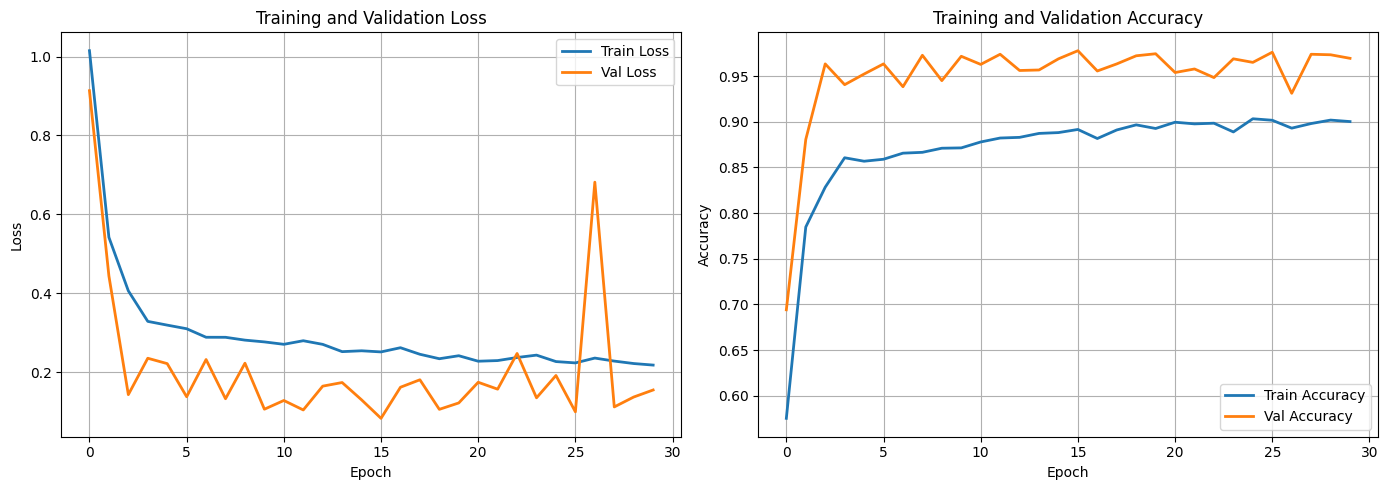

93/93 [==============================] - 1s 5ms/step

TEST METRICS
Accuracy:  0.9301
Precision: 0.9304
Recall:    0.9312
F1-score:  0.9304

CLASSIFICATION REPORT
                    precision    recall  f1-score   support

           WALKING       0.99      1.00      0.99       496
  WALKING_UPSTAIRS       0.96      0.93      0.95       471
WALKING_DOWNSTAIRS       0.93      0.97      0.95       420
           SITTING       0.82      0.87      0.85       491
          STANDING       0.88      0.83      0.85       532
            LAYING       0.99      1.00      1.00       537

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Custom callback для аугментации на лету
class AugmentationCallback(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        # Перемешиваем и аугментируем train данные каждую эпоху
        indices = np.random.permutation(len(X_train_scaled))
        self.model.train_data = (
            augment_batch(X_train_scaled[indices], y_train[indices], augmentation_prob=0.3)[0],
            y_train[indices]
        )

# Обучение
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=155, restore_best_weights=True, verbose=1)

batsh_size = 64
num_epochs = 30

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=num_epochs,
    batch_size=batsh_size,
    callbacks=[lr_scheduler, early_stop], #AugmentationCallback()],
    verbose=1,
)

# Сохранение метрик в списки
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(train_loss, label='Train Loss', linewidth=2)
ax1.plot(val_loss, label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(train_acc, label='Train Accuracy', linewidth=2)
ax2.plot(val_acc, label='Val Accuracy', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Метрики на тесте
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

# Вычисление метрик
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print("\n" + "="*50)
print("TEST METRICS")
print("="*50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print("="*50)

# Classification report
print("\nCLASSIFICATION REPORT")
print("="*50)
target_names = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 
                'SITTING', 'STANDING', 'LAYING']
print(classification_report(y_test, y_pred, target_names=target_names))

In [6]:
# Найти лучшую эпоху по val_accuracy
#best_epoch = np.argmax(history.history['val_accuracy']) + 1
#print(f"Best epoch: {best_epoch}, val_accuracy: {max(history.history['val_accuracy']):.4f}")

# Объединить train и val
X_train_full_scaled = np.concatenate([X_train_scaled, X_val_scaled], axis=0)
y_train_full = np.concatenate([y_train, y_val], axis=0)

print(f"Full train: {X_train_full_scaled.shape}")

# Создать новую модель с теми же параметрами
model_final = build_har_model(bh)
model_final.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Scheduler на train_loss (т.к. val нет)
lr_scheduler = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)

# Обучение на всех данных
history_final = model_final.fit(
    X_train_full_scaled, y_train_full,
    epochs=num_epochs,
    batch_size=batsh_size,
    callbacks=[lr_scheduler, AugmentationCallback()],
    verbose=1
)

# Оценить на test
y_pred_probs = model_final.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"\nFINAL TEST METRICS (trained on all data)")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

# Classification report
print("\nCLASSIFICATION REPORT")
print("="*50)
target_names = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 
                'SITTING', 'STANDING', 'LAYING']
print(classification_report(y_test, y_pred, target_names=target_names))

print('Save model_finel to model_final.h5')
model.save('model_final.h5')
print('Model saved')

Full train: (7352, 128, 9)
Epoch 1/30
115/115 [==============================] - 6s 22ms/step - loss: 1.0231 - accuracy: 0.6051 - lr: 0.0010
Epoch 2/30
115/115 [==============================] - 2s 21ms/step - loss: 0.5538 - accuracy: 0.7879 - lr: 0.0010
Epoch 3/30
115/115 [==============================] - 2s 21ms/step - loss: 0.4234 - accuracy: 0.8260 - lr: 0.0010
Epoch 4/30
115/115 [==============================] - 2s 21ms/step - loss: 0.3660 - accuracy: 0.8463 - lr: 0.0010
Epoch 5/30
115/115 [==============================] - 2s 21ms/step - loss: 0.3410 - accuracy: 0.8481 - lr: 0.0010
Epoch 6/30
115/115 [==============================] - 2s 21ms/step - loss: 0.3115 - accuracy: 0.8618 - lr: 0.0010
Epoch 7/30
115/115 [==============================] - 2s 21ms/step - loss: 0.2940 - accuracy: 0.8664 - lr: 0.0010
Epoch 8/30
115/115 [==============================] - 2s 21ms/step - loss: 0.2688 - accuracy: 0.8817 - lr: 0.0010
Epoch 9/30
115/115 [==============================] - 2s 21ms

In [7]:
# Конвертация в TFLite (реальный размер для MCU):
import tensorflow_model_optimization as tfmot
from tensorflow.keras.models import load_model

model = load_model('model_final.h5')

# === 1. Конвертируем напрямую new_model (после pruning) ===
# TFLite сам уберет GaussianNoise и Dropout при инференсе
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

def representative_dataset():
    for i in range(min(200, len(X_train_full_scaled))):
        yield [X_train_full_scaled[i:i+1].astype(np.float32)]

converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

tflite_model = converter.convert()

with open('har_model_int8.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"TFLite model size: {len(tflite_model) / 1024:.2f} KB")

# === 2. Простая функция предсказания ===
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

def predict_tflite(X):
    predictions = []
    for i in range(len(X)):
        input_data = X[i:i+1].astype(np.float32)
        interpreter.set_tensor(input_details[0]['index'], input_data)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])
        predictions.append(np.argmax(output))
    return np.array(predictions)

# === 3. Проверка метрик ===
y_pred_train = predict_tflite(X_train_full_scaled)
print("\n=== TRAIN METRICS ===")
print(f"Accuracy:  {accuracy_score(y_train_full, y_pred_train):.4f}")

y_pred_test = predict_tflite(X_test_scaled)
print("\n=== TEST METRICS ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test, average='macro'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_test, average='macro'):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_test, average='macro'):.4f}")

INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpf2c3724j\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpf2c3724j\assets
C:\Users\User\.conda\envs\tf-gpu\lib\site-packages\tensorflow\lite\python\convert.py:766: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "


TFLite model size: 62.44 KB

=== TRAIN METRICS ===
Accuracy:  0.9587

=== TEST METRICS ===
Accuracy:  0.9284
Precision: 0.9298
Recall:    0.9299
F1-score:  0.9289


In [13]:
# === INFERENCE BENCHMARK ===
import time

# Загрузка модели
with open('har_model_int8.tflite', 'rb') as f:
    tflite_model = f.read()

# TFLite Interpreter по умолчанию на CPU, но явно укажем:
interpreter = tf.lite.Interpreter(
    model_content=tflite_model,
    num_threads=1  # 1 поток = честный CPU benchmark
)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# === Benchmark ===
n_warmup = 100
n_runs = 1000

# Warmup (прогрев)
for _ in range(n_warmup):
    idx = np.random.randint(0, len(X_test_scaled))
    input_data = X_test_scaled[idx:idx+1].astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    _ = interpreter.get_tensor(output_details[0]['index'])

# Измерение
times = []
with tf.device('/CPU:0'):
    for _ in range(n_runs):
        idx = np.random.randint(0, len(X_test_scaled))
        input_data = X_test_scaled[idx:idx+1].astype(np.float32)
        
        start = time.perf_counter()
        interpreter.set_tensor(input_details[0]['index'], input_data)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])
        end = time.perf_counter()
        
        times.append((end - start) * 1000)  # в мс

times = np.array(times)
print(f"\n=== INFERENCE BENCHMARK ===")
print(f"Model size: {len(tflite_model) / 1024:.2f} KB")
print(f"Runs: {n_runs}")
print(f"Mean:   {times.mean():.3f} ms")
print(f"Median: {np.median(times):.3f} ms")
print(f"Min:    {times.min():.3f} ms")
print(f"Max:    {times.max():.3f} ms")
print(f"Std:    {times.std():.3f} ms")
print(f"FPS:    {1000 / times.mean():.1f}")

# === Сравнение с оригинальной моделью ===
print(f"\n=== COMPARISON ===")
times_orig = []
with tf.device('/CPU:0'):
    for _ in range(n_runs):
        idx = np.random.randint(0, len(X_test_scaled))
        input_data = X_test_scaled[idx:idx+1].astype(np.float32)
        
        start = time.perf_counter()
        _ = model(input_data, training=False)
        end = time.perf_counter()
        
        times_orig.append((end - start) * 1000)

times_orig = np.array(times_orig)
print(f"Original (Keras): {times_orig.mean():.3f} ms")
print(f"TFLite INT8:      {times.mean():.3f} ms")
print(f"Speedup:          {times_orig.mean() / times.mean():.2f}x")


=== INFERENCE BENCHMARK ===
Model size: 62.44 KB
Runs: 1000
Mean:   4.722 ms
Median: 4.677 ms
Min:    4.643 ms
Max:    8.375 ms
Std:    0.170 ms
FPS:    211.8

=== COMPARISON ===
Original (Keras): 43.348 ms
TFLite INT8:      4.722 ms
Speedup:          9.18x


In [9]:
# Способ 1: Посчитать MACs (Multiply-Accumulate operations)
def count_macs(model):
    total_macs = 0
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Conv1D):
            # MACs = output_length * kernel_size * in_channels * out_channels
            config = layer.get_config()
            # Упрощенная оценка
            weights = layer.get_weights()[0]  # (kernel, in_ch, out_ch)
            total_macs += np.prod(weights.shape) * 64  # * среднюю длину
        elif isinstance(layer, tf.keras.layers.Dense):
            weights = layer.get_weights()[0]
            total_macs += np.prod(weights.shape)
    return total_macs

macs = count_macs(model)
print(f"Estimated MACs: {macs/1e6:.2f}M")

# Способ 2: Эмпирическая оценка для Cortex-M4
# Cortex-M4F @ 100 MHz с FPU: ~50-100 MAC/cycle для INT8
# Реальные бенчмарки TFLite Micro на похожих моделях HAR:

mcu_specs = {
    'STM32F4 (100 MHz)': {'mhz': 100, 'mac_per_cycle': 60},
    'STM32L4 (80 MHz)': {'mhz': 80, 'mac_per_cycle': 60},
    'nRF52840 (64 MHz)': {'mhz': 64, 'mac_per_cycle': 40},
    'Arduino Nano 33 BLE (64 MHz)': {'mhz': 64, 'mac_per_cycle': 50},
}

print(f"\n=== CORTEX-M4 ESTIMATION ===")
print(f"Model MACs: {macs/1e6:.2f}M")
for name, spec in mcu_specs.items():
    macs_per_sec = spec['mhz'] * 1e6 * spec['mac_per_cycle']
    inference_ms = (macs / macs_per_sec) * 1000
    print(f"{name}: ~{inference_ms:.1f} ms")

Estimated MACs: 1.32M

=== CORTEX-M4 ESTIMATION ===
Model MACs: 1.32M
STM32F4 (100 MHz): ~0.2 ms
STM32L4 (80 MHz): ~0.3 ms
nRF52840 (64 MHz): ~0.5 ms
Arduino Nano 33 BLE (64 MHz): ~0.4 ms
